<a href="https://colab.research.google.com/github/amoghvd/ML-lab-2547211/blob/LAB-9/LAB_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9: SVM and PCA
## Part A: Support Vector Machine (SVM)

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

data = load_breast_cancer()
X, y = data.data, data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9561
Precision: 0.9714
Recall: 0.9577
F1 Score: 0.9645

Confusion Matrix:
[[41  2]
 [ 3 68]]


## Part B: Principal Component Analysis (PCA)

In [ ]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine_data = load_wine()
X_wine = wine_data.data
y_wine = wine_data.target
feature_names = wine_data.feature_names

wine_df = pd.DataFrame(X_wine, columns=feature_names)
print("Original Feature Ranges:")
display(wine_df.describe().loc[['min', 'max']])

scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

scaled_df = pd.DataFrame(X_wine_scaled, columns=feature_names)
print("\nScaled Feature Ranges (Mean ~0, Std ~1):")
display(scaled_df.describe().loc[['min', 'max']])

Original Feature Ranges:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
min,11.03,0.74,1.36,10.6,70.0,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.0
max,14.83,5.80,3.23,30.0,162.0,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.0



Scaled Feature Ranges (Mean ~0, Std ~1):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
min,-2.434235,-1.432983,-3.679162,-2.671018,-2.088255,-2.107246,-1.695971,-1.868234,-2.069034,-1.634288,-2.094732,-1.895054,-1.493188
max,2.259772,3.109192,3.156325,3.154511,4.371372,2.539515,3.062832,2.402403,3.485073,3.435432,3.301694,1.960915,2.971473


Explained Variance Ratio (PC1, PC2): [0.36198848 0.1920749 ]
Components required for 95% variance: 10


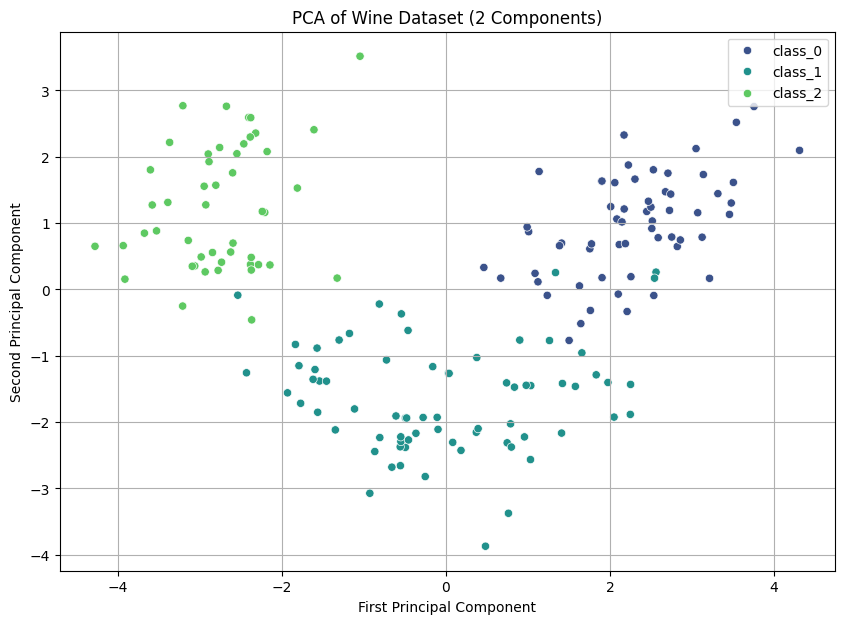

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA

wine_data = load_wine()
X_wine, y_wine = wine_data.data, wine_data.target

scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_wine_scaled)

exp_var = pca_2d.explained_variance_ratio_
print(f"Explained Variance Ratio (PC1, PC2): {exp_var}")

pca_full = PCA().fit(X_wine_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components required for 95% variance: {n_95}")

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=wine_data.target_names[y_wine], palette='viridis')
plt.title('PCA of Wine Dataset (2 Components)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.show()

## Extra Credit: Linear Discriminant Analysis (LDA)

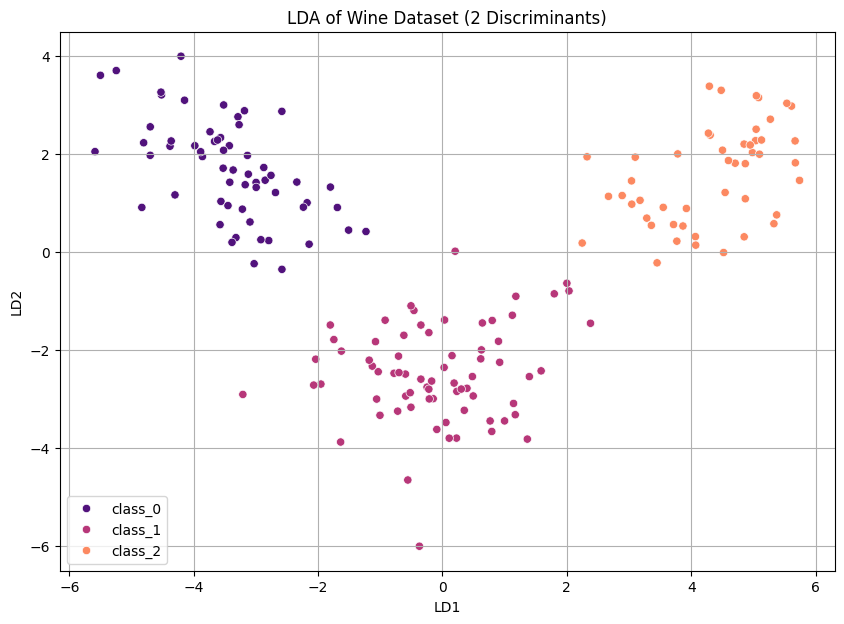

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=wine_data.target_names[y_wine], palette='magma')
plt.title('LDA of Wine Dataset (2 Discriminants)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.grid(True)
plt.show()

### Summary and Observations

**Comparison of PCA and LDA**

In our analysis of the Wine dataset, we observed distinct differences between PCA and LDA. PCA is an unsupervised method that focuses on capturing the directions of maximum variance. In our PCA plot, while there was some visible separation between the wine classes, there was also significant overlap. This is because PCA doesn't "know" about the classes; it simply tries to preserve as much global information as possible. We found that we needed 10 components to retain 95% of the variance, showing that a 2D PCA plot loses a fair amount of detail.

LDA, on the other hand, is a supervised technique. As seen in the LDA plot, the separation between the three wine classes is much more pronounced and distinct. Because LDA specifically calculates the axes that best separate the labels, it is often more effective for dimensionality reduction when the ultimate goal is classification. However, LDA is limited by the number of classes; it can only produce at most $k-1$ components, where $k$ is the number of classes.

**Significance of Components and Efficiency**

Reducing the dataset from 13 features to 2 components significantly improves computational efficiency by reducing the memory footprint and the time required to train downstream models. The first two principal components in Part B represent the directions where the chemical composition of the wines varies the most. While PCA is great for general data compression and noise reduction, LDA is generally preferred when you want to simplify your features without losing the ability to distinguish between your target categories.

**Conclusion**

Supervised learning tools like SVM provide powerful classification boundaries, especially when combined with dimensionality reduction. PCA serves as a robust general-purpose tool for understanding data structure, while LDA excels at feature extraction for classification tasks. Both techniques are essential for handling high-dimensional real-world data where the "curse of dimensionality" might otherwise lead to overfitting or poor model performance.